
## NIO initial Points Density maps


In [1]:

# ============================================================
# Lorenz NIO Visual Discovery Paper
#
# Step 1 : Load NIO Results
# Step 2 : Summary Statistics
# Step 3 : 3D State Space Plot
# Step 4 : Projection Plots
# Step 5 : Sensitivity Density Maps
#
# Assumes:
#   nio_optimized_200_max.csv
#   nio_optimized_200_minimize.csv
#
# Uses:
#   900-step horizon only
#
# Ricardo Calix
# ============================================================


In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.stats import gaussian_kde


In [3]:

# ============================================================
# CONFIGURATION
# ============================================================

## MAX_FILE = "nio_optimized_200_max.csv"
## MIN_FILE = "nio_optimized_200_minimize.csv"

MAX_FILE = "nio_optimized_200_max.csv"


###########################################

random_flag = True        ## Change Only this


if random_flag:
    MIN_FILE    = "random_points.csv"
    name_output = "Random"
else:
    MIN_FILE    = "nio_optimized_200_min.csv"
    name_output = "Min"


###########################################

HORIZON = 900


In [4]:

# ============================================================
# LOAD DATA
# ============================================================

max_df = pd.read_csv(MAX_FILE)
min_df = pd.read_csv(MIN_FILE)


In [5]:

max_df


,Time_steps,point_id,x0,y0,z0
0,300,0,4.334419,9.861786,13.155937
1,300,1,19.695328,0.779478,9.954550
2,300,2,17.409600,0.479961,17.064210
3,300,3,-13.649555,-11.529343,25.880936
4,300,4,-17.842530,-2.126389,24.121515
...,...,...,...,...,...
3995,1300,995,-17.978146,-24.966349,45.860374
3996,1300,996,9.016561,-9.979977,45.979233
3997,1300,997,-9.817795,21.351670,28.764898
3998,1300,998,11.516464,-19.466331,38.763220


In [6]:

min_df


,Time_steps,x0,y0,z0
0,900,-18.811472,12.882393,1.069373
1,900,-11.808344,-20.036456,24.428099
2,900,11.289776,-3.356126,30.224990
3,900,-0.604746,3.070854,40.173117
4,900,6.106643,-9.551703,15.395047
...,...,...,...,...
995,900,13.099173,25.341120,4.682827
996,900,-1.775672,25.946228,4.701282
997,900,-9.199739,-9.498087,39.141564
998,900,-17.943505,-15.880497,43.065822


In [7]:

time_col = [c for c in max_df.columns if "time" in c.lower()][0]


In [8]:

time_col


'Time_steps'

In [9]:

max_data = max_df[max_df[time_col] == HORIZON].copy()



In [10]:

if random_flag == False:
    min_data = min_df[min_df[time_col] == HORIZON].copy()
else:
    min_data = min_df.copy()    




In [11]:

max_data


,Time_steps,point_id,x0,y0,z0
2000,900,0,5.537384,7.429584,17.617476
2001,900,1,15.820267,-28.928047,3.342888
2002,900,2,-14.631885,4.445206,46.085743
2003,900,3,5.562977,-11.697836,9.759507
2004,900,4,10.387220,-10.459404,42.008293
...,...,...,...,...,...
2995,900,995,-15.646301,-14.692164,9.030634
2996,900,996,1.320507,0.247578,33.008760
2997,900,997,15.422245,-24.831097,46.137160
2998,900,998,-5.499721,0.647278,44.645885


In [12]:

min_data


,Time_steps,x0,y0,z0
0,900,-18.811472,12.882393,1.069373
1,900,-11.808344,-20.036456,24.428099
2,900,11.289776,-3.356126,30.224990
3,900,-0.604746,3.070854,40.173117
4,900,6.106643,-9.551703,15.395047
...,...,...,...,...
995,900,13.099173,25.341120,4.682827
996,900,-1.775672,25.946228,4.701282
997,900,-9.199739,-9.498087,39.141564
998,900,-17.943505,-15.880497,43.065822


In [13]:

print("\nLoaded Data")
print("----------------------------")
print("Max-sensitive points :", len(max_data))
print("Min-sensitive points :", len(min_data))



Loaded Data
----------------------------
Max-sensitive points : 1000
Min-sensitive points : 1000




## SUMMARY STATISTICS


In [14]:

print("\n")
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)




SUMMARY STATISTICS


In [15]:

def summarize(df, label):

    stats = pd.DataFrame({
        "Mean": df[["x0","y0","z0"]].mean(),
        "Std":  df[["x0","y0","z0"]].std(),
        "Min":  df[["x0","y0","z0"]].min(),
        "Max":  df[["x0","y0","z0"]].max()
    })

    print("\n")
    print(label)
    print("-"*50)
    print(stats)


In [16]:

summarize(max_data, "MAX-SENSITIVE")




MAX-SENSITIVE
--------------------------------------------------
         Mean        Std        Min        Max
x0   0.105192  11.816708 -19.773264  19.779350
y0  -0.091881  16.934206 -29.452640  29.630203
z0  24.849367  14.285935   0.730564  49.861233


In [17]:

summarize(min_data, "MIN-SENSITIVE")




MIN-SENSITIVE
--------------------------------------------------
         Mean        Std        Min        Max
x0  -0.045958  11.436336 -19.874495  19.974802
y0  -0.936242  17.249262 -29.833778  29.847343
z0  24.781759  14.425646   0.032748  49.988600




## 3D STATE SPACE


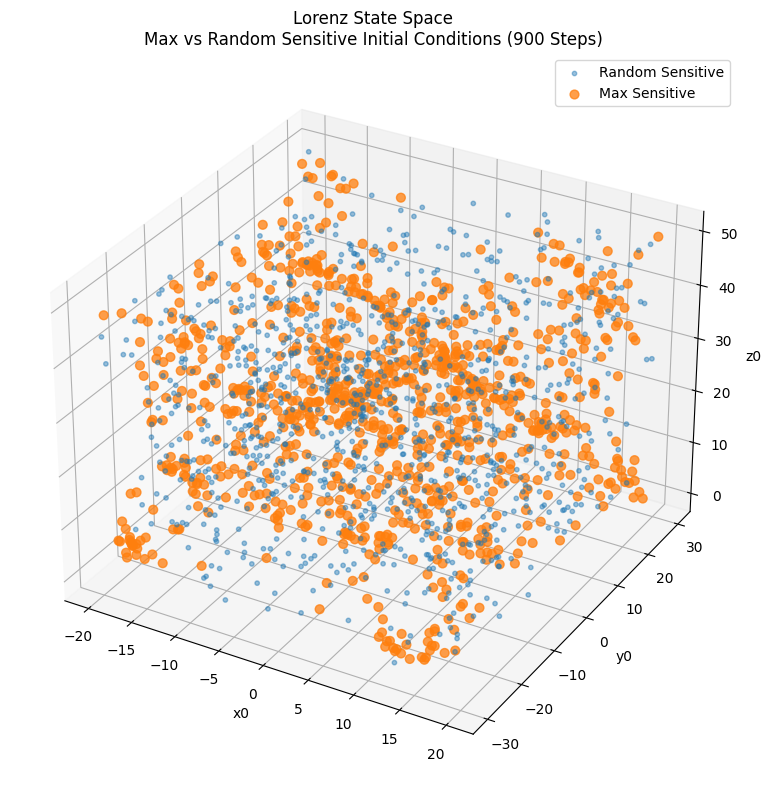

In [18]:

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)


ax.scatter(
    min_data["x0"],
    min_data["y0"],
    min_data["z0"],
    s=10,
    alpha=0.45,
    label=name_output + " Sensitive"
)

ax.scatter(
    max_data["x0"],
    max_data["y0"],
    max_data["z0"],
    s=40,
    alpha=0.75,
    label="Max Sensitive"
)

ax.set_xlabel("x0")
ax.set_ylabel("y0")
ax.set_zlabel("z0")

ax.set_title(
    f"Lorenz State Space\nMax vs " + name_output + " Sensitive Initial Conditions (900 Steps)"
)

ax.legend()

plt.tight_layout()
plt.savefig(
    name_output + "_Figure1_3D_StateSpace.png",
    dpi=300
)

plt.show()





## PROJECTION PLOTS


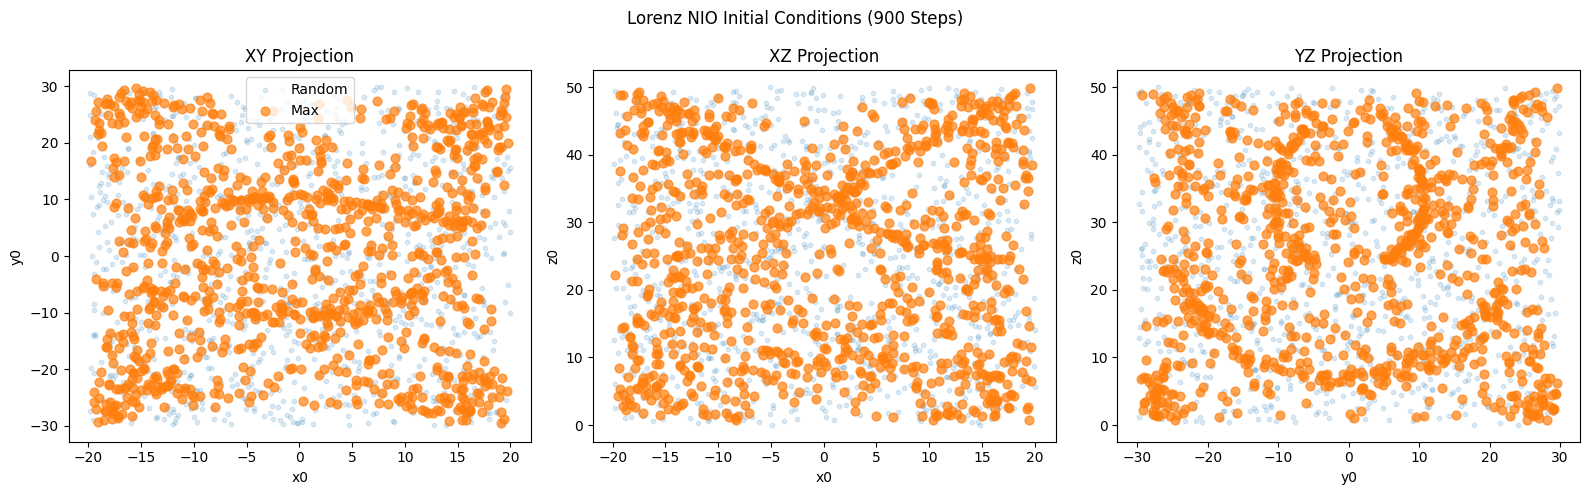

In [19]:


fig, axs = plt.subplots(
    1,
    3,
    figsize=(16,5)
)


# ------------------------------------------------------------
# XY
# ------------------------------------------------------------

axs[0].scatter(
    min_data["x0"],
    min_data["y0"],
    s=10,
    alpha=0.15,
    label=name_output + ""
)

axs[0].scatter(
    max_data["x0"],
    max_data["y0"],
    s=40,
    alpha=0.7,
    label="Max"
)

axs[0].set_title("XY Projection")
axs[0].set_xlabel("x0")
axs[0].set_ylabel("y0")

# ------------------------------------------------------------
# XZ
# ------------------------------------------------------------

axs[1].scatter(
    min_data["x0"],
    min_data["z0"],
    s=10,
    alpha=0.15
)

axs[1].scatter(
    max_data["x0"],
    max_data["z0"],
    s=40,
    alpha=0.7
)

axs[1].set_title("XZ Projection")
axs[1].set_xlabel("x0")
axs[1].set_ylabel("z0")

# ------------------------------------------------------------
# YZ
# ------------------------------------------------------------

axs[2].scatter(
    min_data["y0"],
    min_data["z0"],
    s=10,
    alpha=0.15
)

axs[2].scatter(
    max_data["y0"],
    max_data["z0"],
    s=40,
    alpha=0.7
)

axs[2].set_title("YZ Projection")
axs[2].set_xlabel("y0")
axs[2].set_ylabel("z0")


axs[0].legend()

plt.suptitle(
    f"Lorenz NIO Initial Conditions ({HORIZON} Steps)"
)

plt.tight_layout()

plt.savefig(
    name_output + "Figure2_ProjectionPlots.png",
    dpi=300
)

plt.show()




## SENSITIVITY DENSITY MAPS

* rho_max - rho_min



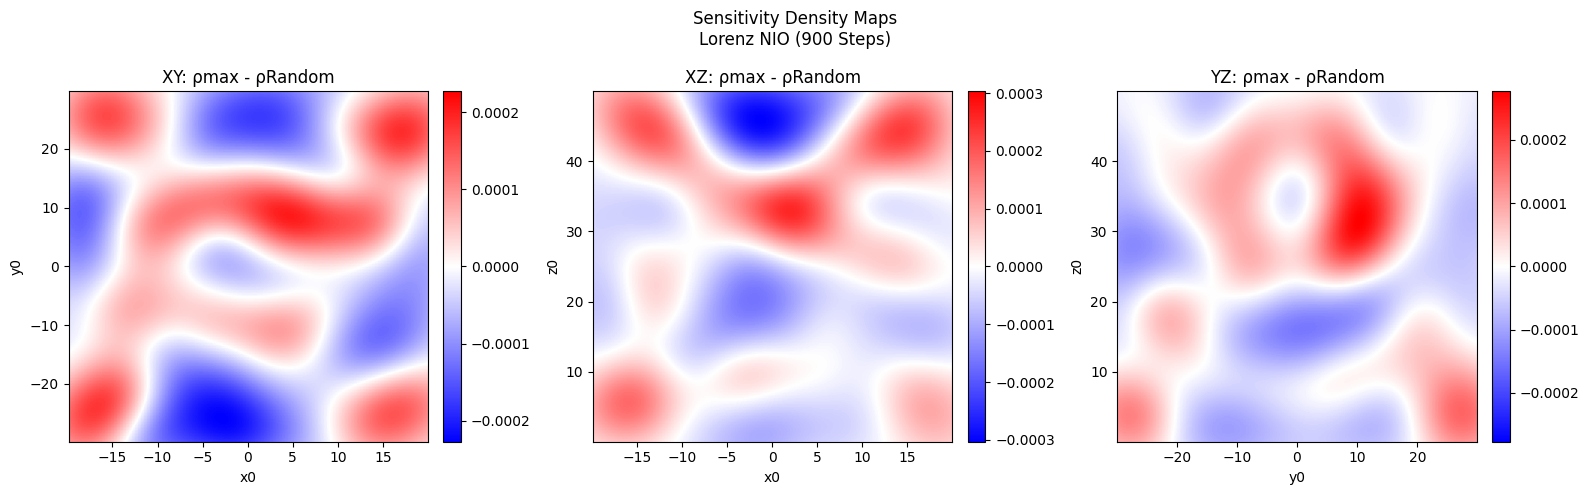

In [20]:

fig, axs = plt.subplots(
    1,
    3,
    figsize=(16,5)
)

pairs = [
    ("x0","y0","XY"),
    ("x0","z0","XZ"),
    ("y0","z0","YZ")
]


for ax, (a,b,title) in zip(axs,pairs):

    all_a = np.concatenate([
        max_data[a],
        min_data[a]
    ])

    all_b = np.concatenate([
        max_data[b],
        min_data[b]
    ])

    grid_a = np.linspace(
        all_a.min(),
        all_a.max(),
        120
    )

    grid_b = np.linspace(
        all_b.min(),
        all_b.max(),
        120
    )

    A,B = np.meshgrid(
        grid_a,
        grid_b
    )

    kde_max = gaussian_kde(
        np.vstack([
            max_data[a],
            max_data[b]
        ])
    )

    kde_min = gaussian_kde(
        np.vstack([
            min_data[a],
            min_data[b]
        ])
    )

    rho_max = kde_max(
        np.vstack([
            A.ravel(),
            B.ravel()
        ])
    ).reshape(A.shape)

    rho_min = kde_min(
        np.vstack([
            A.ravel(),
            B.ravel()
        ])
    ).reshape(A.shape)

    density_difference = (
        rho_max - rho_min
    )

    vmax = np.abs(
        density_difference
    ).max()

    image = ax.imshow(
        density_difference,
        origin="lower",
        extent=[
            grid_a.min(),
            grid_a.max(),
            grid_b.min(),
            grid_b.max()
        ],
        aspect="auto",
        cmap="bwr",
        vmin=-vmax,
        vmax=vmax
    )

    ax.set_title(
        f"{title}: ρmax - ρ" + name_output
    )

    ax.set_xlabel(a)
    ax.set_ylabel(b)

    plt.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

 
plt.suptitle(
    f"Sensitivity Density Maps\nLorenz NIO ({HORIZON} Steps)"
)

plt.tight_layout()

plt.savefig(
    name_output + "Figure3_DensityMaps.png",
    dpi=300
)

plt.show()




## Broken up approach of the previous 




## CREATE XY GRID

* We first create a common coordinate system that both populations will use


In [21]:



x_max = max_data["x0"]
y_max = max_data["y0"]

x_min = min_data["x0"]
y_min = min_data["y0"]

xmin = min(x_max.min(), x_min.min())
xmax = max(x_max.max(), x_min.max())

ymin = min(y_max.min(), y_min.min())
ymax = max(y_max.max(), y_min.max())

grid_x = np.linspace(xmin, xmax, 120)
grid_y = np.linspace(ymin, ymax, 120)

X_xy, Y_xy = np.meshgrid(
    grid_x,
    grid_y
)


In [22]:

grid_x


array([-19.87449519, -19.53962715, -19.20475911, -18.86989107,
       -18.53502303, -18.20015499, -17.86528695, -17.53041891,
       -17.19555087, -16.86068283, -16.52581479, -16.19094675,
       -15.85607871, -15.52121067, -15.18634263, -14.85147459,
       -14.51660655, -14.18173851, -13.84687047, -13.51200243,
       -13.17713439, -12.84226635, -12.50739831, -12.17253027,
       -11.83766223, -11.50279419, -11.16792615, -10.83305811,
       -10.49819007, -10.16332203,  -9.82845399,  -9.49358595,
        -9.15871791,  -8.82384987,  -8.48898183,  -8.15411379,
        -7.81924575,  -7.48437771,  -7.14950967,  -6.81464163,
        -6.47977359,  -6.14490555,  -5.81003751,  -5.47516947,
        -5.14030143,  -4.80543339,  -4.47056535,  -4.13569731,
        -3.80082927,  -3.46596123,  -3.13109319,  -2.79622515,
        -2.46135711,  -2.12648907,  -1.79162103,  -1.45675299,
        -1.12188495,  -0.78701691,  -0.45214887,  -0.11728083,
         0.21758721,   0.55245525,   0.88732329,   1.22

In [23]:

grid_y


array([-29.83377844, -29.33225641, -28.83073437, -28.32921234,
       -27.82769031, -27.32616828, -26.82464624, -26.32312421,
       -25.82160218, -25.32008014, -24.81855811, -24.31703608,
       -23.81551405, -23.31399201, -22.81246998, -22.31094795,
       -21.80942591, -21.30790388, -20.80638185, -20.30485982,
       -19.80333778, -19.30181575, -18.80029372, -18.29877169,
       -17.79724965, -17.29572762, -16.79420559, -16.29268355,
       -15.79116152, -15.28963949, -14.78811746, -14.28659542,
       -13.78507339, -13.28355136, -12.78202932, -12.28050729,
       -11.77898526, -11.27746323, -10.77594119, -10.27441916,
        -9.77289713,  -9.27137509,  -8.76985306,  -8.26833103,
        -7.766809  ,  -7.26528696,  -6.76376493,  -6.2622429 ,
        -5.76072087,  -5.25919883,  -4.7576768 ,  -4.25615477,
        -3.75463273,  -3.2531107 ,  -2.75158867,  -2.25006664,
        -1.7485446 ,  -1.24702257,  -0.74550054,  -0.2439785 ,
         0.25754353,   0.75906556,   1.26058759,   1.76


## KDE for Max-Sensitive Points


In [24]:



kde_max_xy = gaussian_kde(
    np.vstack([
        x_max,
        y_max
    ])
)

rho_max_xy = kde_max_xy(
    np.vstack([
        X_xy.ravel(),
        Y_xy.ravel()
    ])
).reshape(X_xy.shape)


In [25]:

kde_max_xy


In [26]:

rho_max_xy


array([[0.00020184, 0.00021424, 0.00022602, ..., 0.00018612, 0.00017307,
        0.00016003],
       [0.00021588, 0.00022939, 0.00024227, ..., 0.00020052, 0.00018651,
        0.00017249],
       [0.00022943, 0.00024405, 0.00025804, ..., 0.0002146 , 0.00019965,
        0.00018469],
       ...,
       [0.00018808, 0.00020267, 0.00021712, ..., 0.00024144, 0.00022899,
        0.00021593],
       [0.00017733, 0.0001912 , 0.00020494, ..., 0.00022392, 0.00021254,
        0.00020058],
       [0.00016605, 0.00017914, 0.00019211, ..., 0.0002064 , 0.00019607,
        0.00018518]])


## KDE for Min-Sensitive Points


In [27]:



kde_min_xy = gaussian_kde(
    np.vstack([
        x_min,
        y_min
    ])
)

rho_min_xy = kde_min_xy(
    np.vstack([
        X_xy.ravel(),
        Y_xy.ravel()
    ])
).reshape(X_xy.shape)


In [28]:

# ==================================================
# 
# DIFFERENCE MAP
# ==================================================

rho_diff_xy = (
    rho_max_xy - rho_min_xy
)


In [29]:

rho_diff_xy


array([[1.04621404e-04, 1.08839977e-04, 1.12198774e-04, ...,
        6.74491544e-05, 6.24714135e-05, 5.75380154e-05],
       [1.11398329e-04, 1.16139349e-04, 1.20006772e-04, ...,
        7.43905290e-05, 6.90268531e-05, 6.36895937e-05],
       [1.17658402e-04, 1.22929407e-04, 1.27321862e-04, ...,
        8.12981799e-05, 7.55733377e-05, 6.98532690e-05],
       ...,
       [7.97292052e-05, 8.70223094e-05, 9.42449734e-05, ...,
        9.68927650e-05, 9.34338566e-05, 8.94526882e-05],
       [7.50081377e-05, 8.19254116e-05, 8.87799642e-05, ...,
        8.79775780e-05, 8.49964146e-05, 8.15189522e-05],
       [6.99354508e-05, 7.64428470e-05, 8.28956567e-05, ...,
        7.91897609e-05, 7.66644967e-05, 7.36703857e-05]])

In [30]:

# ==================================================

# XZ PROJECTION
# ==================================================

x_max = max_data["x0"]
z_max = max_data["z0"]

x_min = min_data["x0"]
z_min = min_data["z0"]

xmin = min(x_max.min(), x_min.min())
xmax = max(x_max.max(), x_min.max())

zmin = min(z_max.min(), z_min.min())
zmax = max(z_max.max(), z_min.max())

grid_x = np.linspace(xmin, xmax, 120)
grid_z = np.linspace(zmin, zmax, 120)

X_xz, Z_xz = np.meshgrid(
    grid_x,
    grid_z
)

kde_max_xz = gaussian_kde(
    np.vstack([
        x_max,
        z_max
    ])
)

rho_max_xz = kde_max_xz(
    np.vstack([
        X_xz.ravel(),
        Z_xz.ravel()
    ])
).reshape(X_xz.shape)

kde_min_xz = gaussian_kde(
    np.vstack([
        x_min,
        z_min
    ])
)

rho_min_xz = kde_min_xz(
    np.vstack([
        X_xz.ravel(),
        Z_xz.ravel()
    ])
).reshape(X_xz.shape)

rho_diff_xz = (
    rho_max_xz -
    rho_min_xz
)


In [31]:

# ==================================================
# YZ PROJECTION
# ==================================================

y_max = max_data["y0"]
z_max = max_data["z0"]

y_min = min_data["y0"]
z_min = min_data["z0"]

ymin = min(y_max.min(), y_min.min())
ymax = max(y_max.max(), y_min.max())

zmin = min(z_max.min(), z_min.min())
zmax = max(z_max.max(), z_min.max())

grid_y = np.linspace(ymin, ymax, 120)
grid_z = np.linspace(zmin, zmax, 120)

Y_yz, Z_yz = np.meshgrid(
    grid_y,
    grid_z
)

kde_max_yz = gaussian_kde(
    np.vstack([
        y_max,
        z_max
    ])
)

rho_max_yz = kde_max_yz(
    np.vstack([
        Y_yz.ravel(),
        Z_yz.ravel()
    ])
).reshape(Y_yz.shape)

kde_min_yz = gaussian_kde(
    np.vstack([
        y_min,
        z_min
    ])
)

rho_min_yz = kde_min_yz(
    np.vstack([
        Y_yz.ravel(),
        Z_yz.ravel()
    ])
).reshape(Y_yz.shape)

rho_diff_yz = (
    rho_max_yz -
    rho_min_yz
)


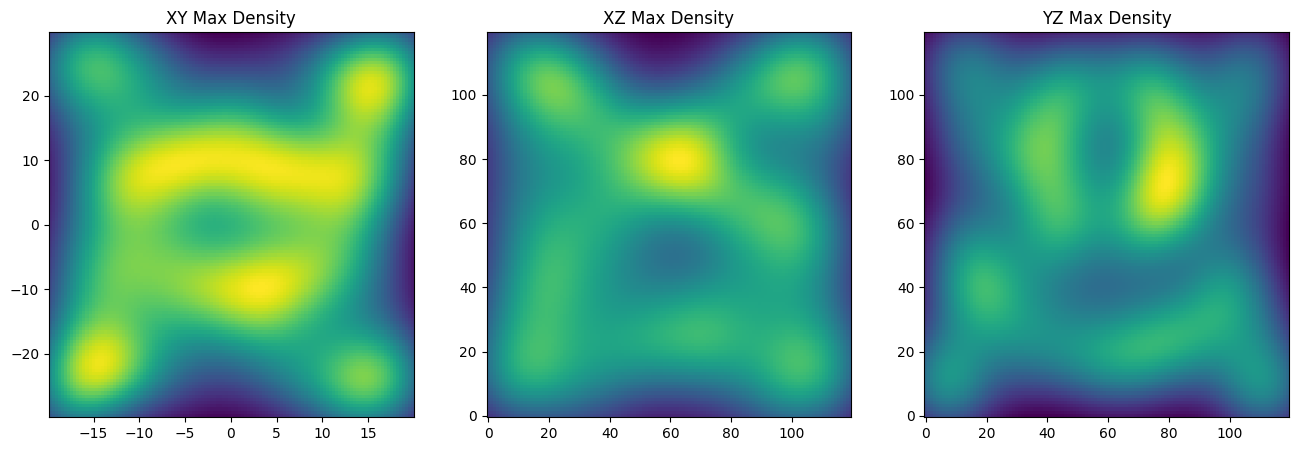

In [32]:

## Where does NIO find highly sensitive initial conditions?

fig, axs = plt.subplots(1,3,figsize=(16,5))

axs[0].imshow(
    rho_max_xy,
    origin="lower",
    extent=[
        grid_x.min(),
        grid_x.max(),
        grid_y.min(),
        grid_y.max()
    ],
    aspect="auto"
)

axs[0].set_title("XY Max Density")

axs[1].imshow(
    rho_max_xz,
    origin="lower",
    aspect="auto"
)

axs[1].set_title("XZ Max Density")

axs[2].imshow(
    rho_max_yz,
    origin="lower",
    aspect="auto"
)

axs[2].set_title("YZ Max Density")

plt.show()


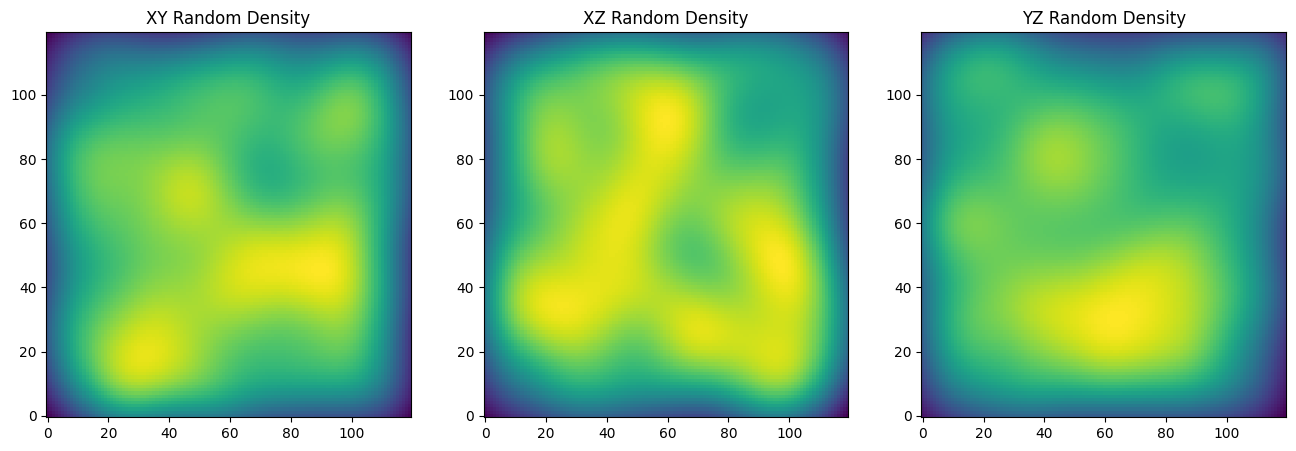

In [33]:

## Where does NIO find insensitive initial conditions?

fig, axs = plt.subplots(1,3,figsize=(16,5))

axs[0].imshow(rho_min_xy,origin="lower",aspect="auto")
axs[0].set_title("XY " + name_output + " Density")

axs[1].imshow(rho_min_xz,origin="lower",aspect="auto")
axs[1].set_title("XZ " + name_output + " Density")

axs[2].imshow(rho_min_yz,origin="lower",aspect="auto")
axs[2].set_title("YZ " + name_output + " Density")

plt.show()


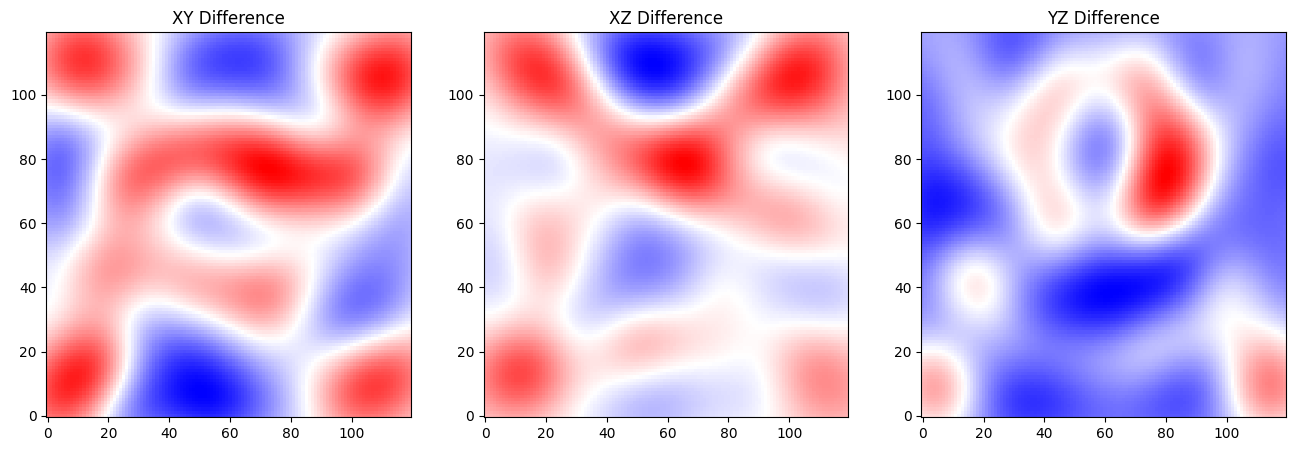

In [34]:

## Where do max-sensitive and min-sensitive regions differ?

fig, axs = plt.subplots(1,3,figsize=(16,5))

axs[0].imshow(
    rho_diff_xy,
    origin="lower",
    cmap="bwr",
    aspect="auto"
)

axs[0].set_title("XY Difference")

axs[1].imshow(
    rho_diff_xz,
    origin="lower",
    cmap="bwr",
    aspect="auto"
)

axs[1].set_title("XZ Difference")

axs[2].imshow(
    rho_diff_yz,
    origin="lower",
    cmap="bwr",
    aspect="auto"
)

axs[2].set_title("YZ Difference")

plt.show()



## More simplification 


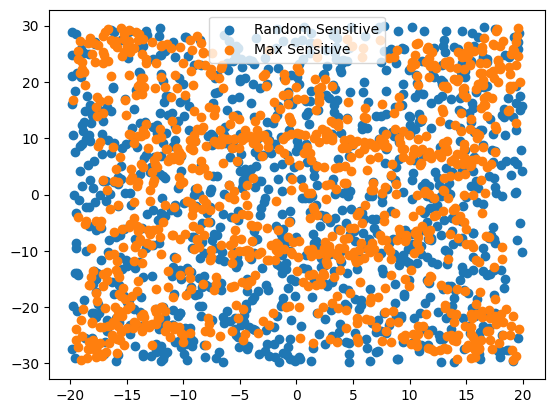

In [35]:


plt.scatter(
    min_data["x0"],
    min_data["y0"],
    label=name_output + " Sensitive"
)

plt.scatter(
    max_data["x0"],
    max_data["y0"],
    label="Max Sensitive"
)


plt.legend()
plt.show()


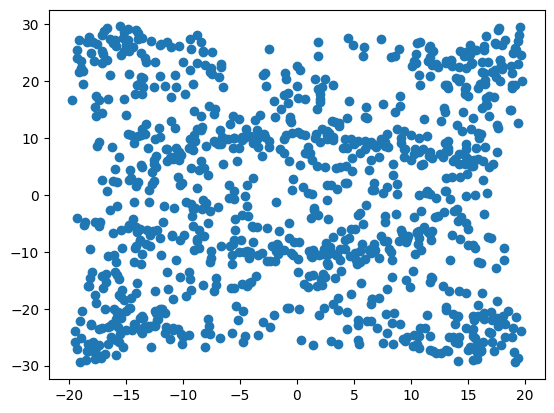

In [36]:

x = max_data["x0"]
y = max_data["y0"]

plt.scatter(x,y)
plt.show()


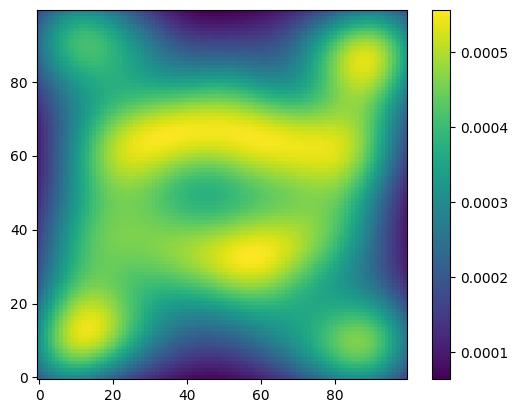

In [37]:

kde = gaussian_kde(
    np.vstack([x,y])
)

grid_x = np.linspace(x.min(),x.max(),100)
grid_y = np.linspace(y.min(),y.max(),100)

X,Y = np.meshgrid(
    grid_x,
    grid_y
)

rho = kde(
    np.vstack([
        X.ravel(),
        Y.ravel()
    ])
)

rho = rho.reshape(
    X.shape
)

plt.imshow(
    rho,
    origin="lower"
)

plt.colorbar()
plt.show()



## Super Simple Again


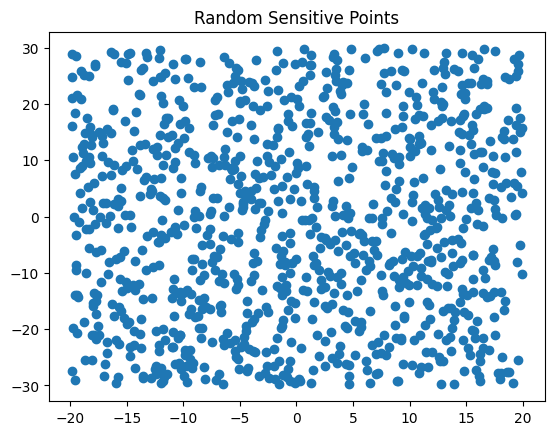

In [38]:

x = min_data["x0"]
y = min_data["y0"]

plt.scatter(x,y)
plt.title(name_output + " Sensitive Points")
plt.show()


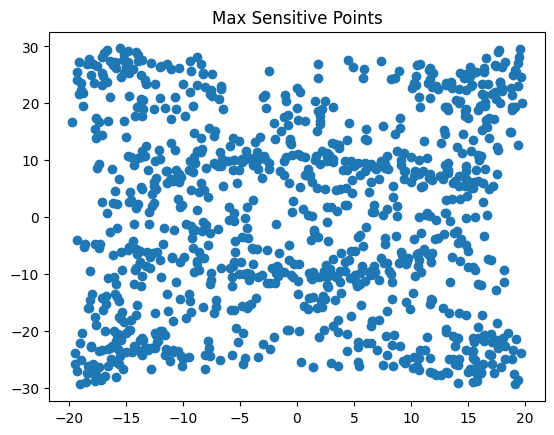

In [39]:

x = max_data["x0"]
y = max_data["y0"]

plt.scatter(x,y)
plt.title("Max Sensitive Points")
plt.show()


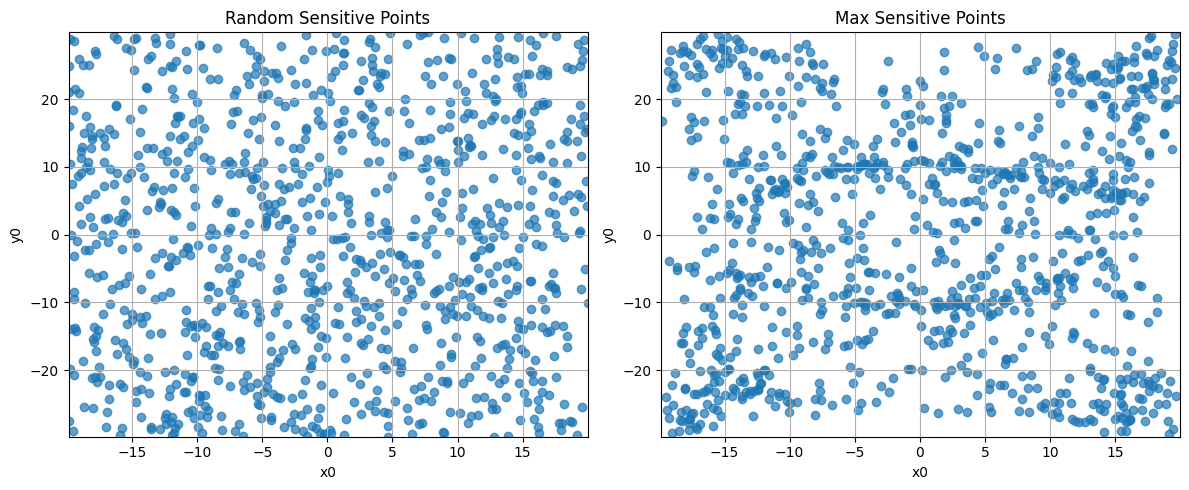

In [40]:

import matplotlib.pyplot as plt

# ---------------------------------------
# Side-by-side comparison
# ---------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Common axis limits
xmin = min(min_data["x0"].min(), max_data["x0"].min())
xmax = max(min_data["x0"].max(), max_data["x0"].max())

ymin = min(min_data["y0"].min(), max_data["y0"].min())
ymax = max(min_data["y0"].max(), max_data["y0"].max())

# ---------------------------------------
# Min-sensitive points
# ---------------------------------------

ax[0].scatter(
    min_data["x0"],
    min_data["y0"],
    alpha=0.7
)

ax[0].set_title(name_output + " Sensitive Points")
ax[0].set_xlabel("x0")
ax[0].set_ylabel("y0")
ax[0].set_xlim(xmin, xmax)
ax[0].set_ylim(ymin, ymax)
ax[0].grid(True)

# ---------------------------------------
# Max-sensitive points
# ---------------------------------------

ax[1].scatter(
    max_data["x0"],
    max_data["y0"],
    alpha=0.7
)

ax[1].set_title("Max Sensitive Points")
ax[1].set_xlabel("x0")
ax[1].set_ylabel("y0")
ax[1].set_xlim(xmin, xmax)
ax[1].set_ylim(ymin, ymax)
ax[1].grid(True)

plt.tight_layout()
plt.show()


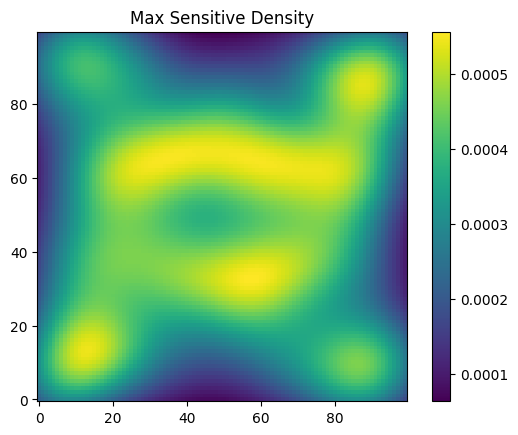

In [41]:

x = max_data["x0"]
y = max_data["y0"]

kde = gaussian_kde(
    np.vstack([x,y])
)

X,Y = np.meshgrid(
    np.linspace(x.min(),x.max(),100),
    np.linspace(y.min(),y.max(),100)
)

rho_max = kde(
    np.vstack([
        X.ravel(),
        Y.ravel()
    ])
).reshape(X.shape)

plt.imshow(
    rho_max,
    origin="lower"
)

plt.colorbar()
plt.title("Max Sensitive Density")
plt.show()


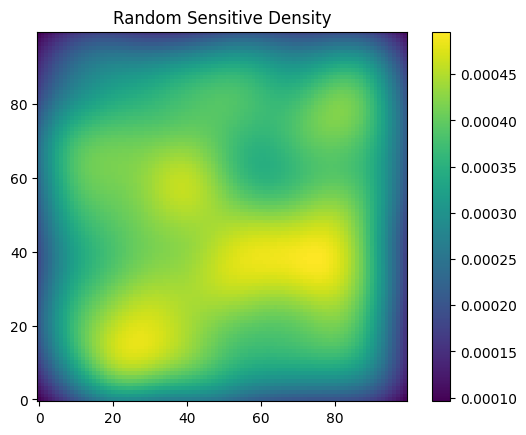

In [42]:

x = min_data["x0"]
y = min_data["y0"]

kde = gaussian_kde(
    np.vstack([x,y])
)

X,Y = np.meshgrid(
    np.linspace(x.min(),x.max(),100),
    np.linspace(y.min(),y.max(),100)
)

rho_min = kde(
    np.vstack([
        X.ravel(),
        Y.ravel()
    ])
).reshape(X.shape)

plt.imshow(
    rho_min,
    origin="lower"
)

plt.colorbar()
plt.title( name_output + " Sensitive Density")
plt.show()


In [43]:

np.vstack([x,y])


array([[-18.81147181, -11.80834419,  11.28977602, ...,  -9.19973892,
        -17.9435049 ,   7.4535754 ],
       [ 12.88239347, -20.03645619,  -3.35612639, ...,  -9.49808744,
        -15.88049673, -24.18889881]])

In [44]:

rho_diff = rho_max - rho_min


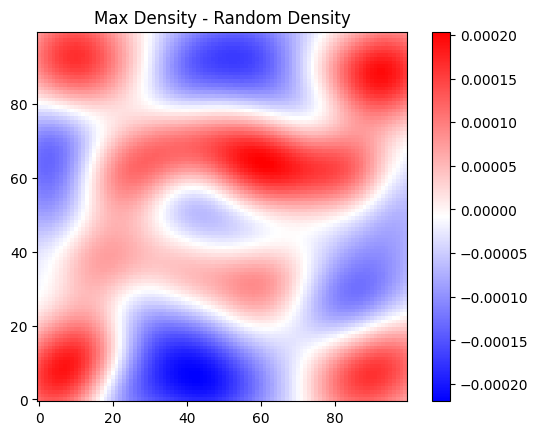

In [45]:

plt.imshow(
    rho_diff,
    origin="lower",
    cmap="bwr"
)

plt.colorbar()
plt.title("Max Density - " + name_output + " Density")
plt.show()



## Generate case 3 - Random data


In [ ]:




# ==================================================
# RANDOM BASELINE
# ==================================================

import pandas as pd
import numpy as np

N = 1000

random_x = np.random.uniform(
    -20,
    20,
    N
)

random_y = np.random.uniform(
    -30,
    30,
    N
)

random_z = np.random.uniform(
    0,
    50,
    N
)

random_df = pd.DataFrame({
    "Time_steps": 900,
    "x0"        : random_x,
    "y0"        : random_y,
    "z0"        : random_z
})

random_df.to_csv(
    "random_points.csv",
    index=False
)

print(random_df.head())

print()
print("Saved:")
print("random_points.csv")
print("Number of points:", len(random_df))






